#import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


#load the dataset


In [3]:
df= pd.read_csv("loan_approval.csv")

#explore dataset

In [4]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [6]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [7]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


#encode categorical data

In [8]:
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
  df[col]=le.fit_transform(df[col])


#visualizations

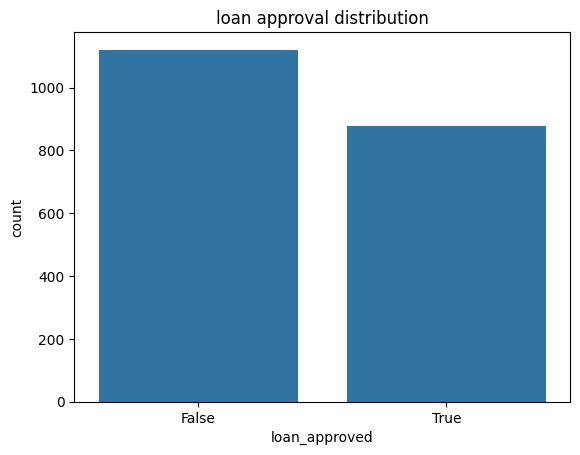

In [10]:
sns.countplot(x='loan_approved',data=df)
plt.title("loan approval distribution")
plt.show()

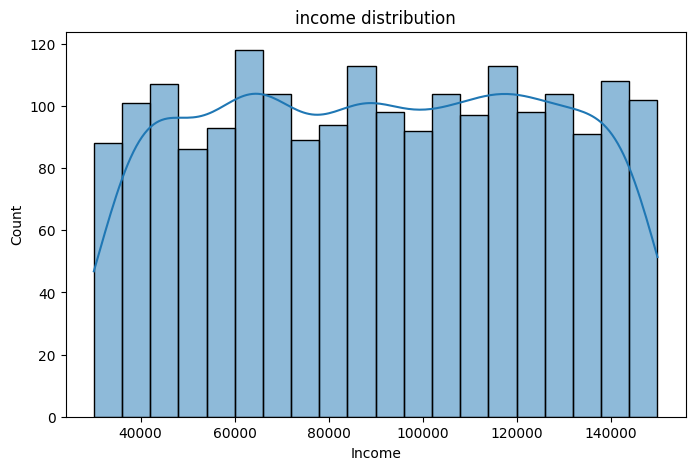

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['income'],bins=20,kde= True)
plt.title("income distribution")
plt.xlabel("Income")
plt.show()

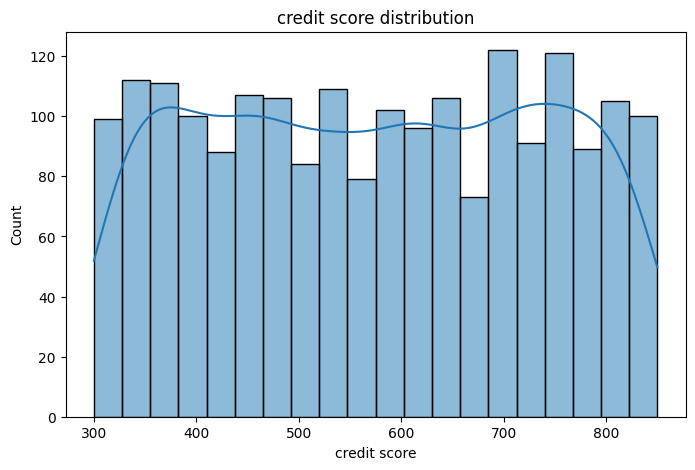

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['credit_score'],bins=20,kde= True)
plt.title("credit score distribution")
plt.xlabel("credit score")
plt.show()

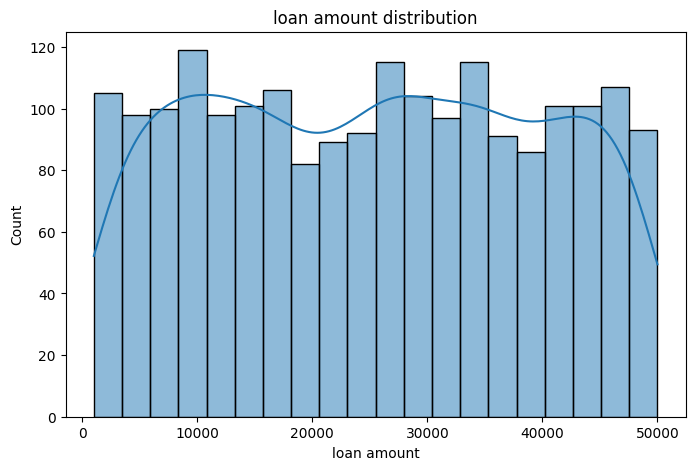

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amount'],bins=20,kde= True)
plt.title("loan amount distribution")
plt.xlabel("loan amount")
plt.show()

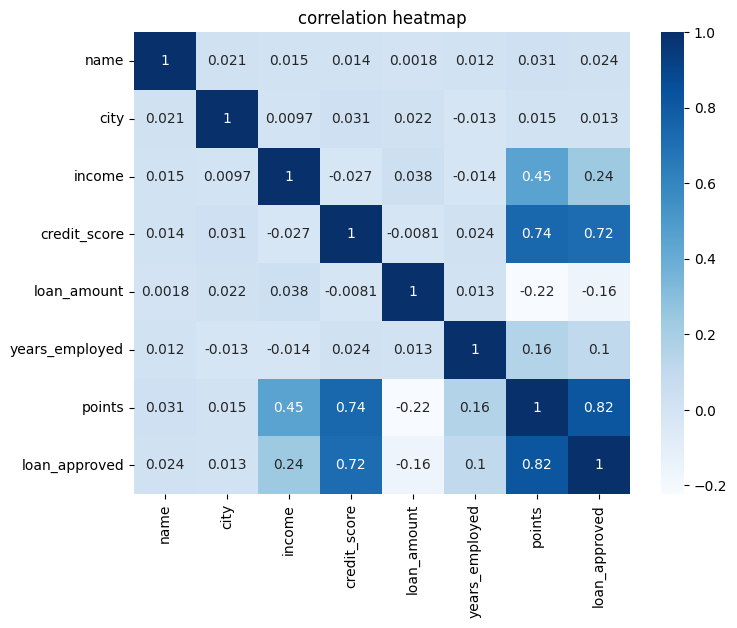

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True),annot = True, cmap= "Blues")
plt.title("correlation heatmap")

plt.show()

#split features and target

In [17]:
X= df.drop("loan_approved", axis=1)
y=df["loan_approved"]

#encode categorical columns

In [18]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

X["name"]= le.fit_transform(X["name"])
X["city"]=le.fit_transform(X["city"])

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

#train decision tree

In [20]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
y_pred= dt.predict(X_test)

#accuracy

In [22]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 1.0


#confusion matrix

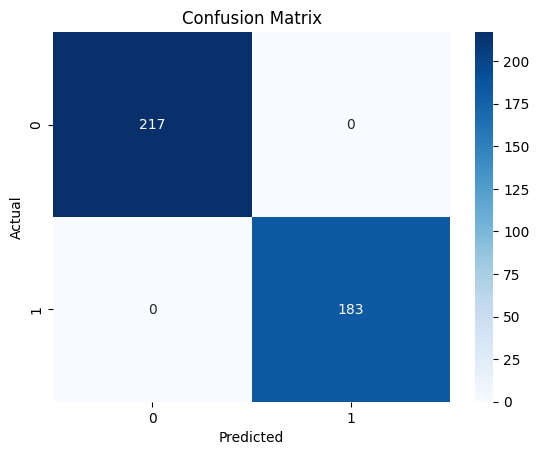

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot =True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#classification report

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       217
        True       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



#conclusion

This project successfully demonstrates the complete Machine Learning workflow for loan approval prediction. The dataset was cleaned and preprocessed by handling categorical features and preparing the data for training. Exploratory Data Analysis (EDA) was performed to understand feature relationships. Decision Tree and Random Forest classifiers were trained and evaluated, with Random Forest providing improved prediction performance. This project highlights practical skills in data preprocessing, visualization, model building, and evaluation using Python and Scikit-learn.